In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_boston     

from sklearn.neighbors import KNeighborsRegressor

from sklearn.linear_model import LinearRegression



In [2]:
# 1. Execute the function to load the Bunch object
from sklearn.datasets import load_boston
boston = load_boston()

# 2. Extract arrays into the DataFrame constructor
df = pd.DataFrame(data = boston.data, columns= boston.feature_names)

# 3. (Optional) Append target prices column
df["price"] = boston.target

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


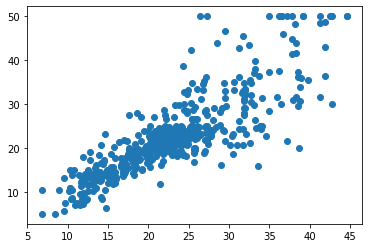

In [3]:
X ,y = load_boston(return_X_y=True)

model = KNeighborsRegressor()

model.fit(X,y)

prediction = model.predict(X)

plt.scatter(prediction , y )


##### Pipeline 

Pipline in sklearn is a way to streamline a machine learning workflow by chaining together multiple steps, such as preprocessing, feature selection, and model training, into a single object. This allows for easier management of the entire process, ensuring that the same transformations are applied consistently during both training and testing phases. Pipelines help prevent data leakage and make it easier to perform hyperparameter tuning and cross-validation.


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


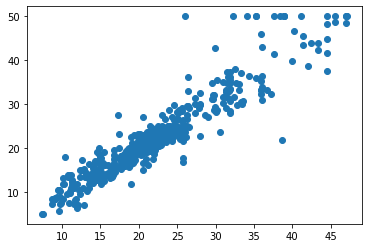

In [5]:
mod = KNeighborsRegressor().fit(X,y)

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model",KNeighborsRegressor())
]
)

pipe.fit(X,y) # fit is used to train with data

pred = pipe.predict(X)  # predict is used to predict after training

plt.scatter(pred, y)

##### GridsearchCV

Grid SearchCV is a method to perform hyperparameter tuning in order to determine the optimal values for a given model. It exhaustively considers all parameter combinations and evaluates the model's performance using cross-validation. This process helps in finding the best hyperparameters that yield the highest accuracy or other performance metrics.

In [6]:
from sklearn.model_selection import GridSearchCV

In [7]:
X, y = load_boston(return_X_y=True)

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model",KNeighborsRegressor())
]
)

In [8]:
mod = GridSearchCV(estimator= pipe,
                   param_grid={'model__n_neighbors': [1,2,3,4,5,6,7,8,9,10]},
                   cv =3)

mod.fit(X,y);
pd.DataFrame(mod.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004366,0.002319,0.007491,0.003103,1,{'model__n_neighbors': 1},0.226933,0.432998,0.127635,0.262522,0.127179,10
1,0.005680,0.001897,0.006899,0.001296,2,{'model__n_neighbors': 2},0.358216,0.409229,0.172294,0.313246,0.101821,9
2,0.003652,0.004058,0.041722,0.055680,3,{'model__n_neighbors': 3},0.413515,0.476651,0.318534,0.402900,0.064986,1
3,0.004168,0.001290,0.004088,0.000224,4,{'model__n_neighbors': 4},0.475349,0.402495,0.273014,0.383619,0.083675,7
4,0.003028,0.001433,0.004407,0.000490,5,{'model__n_neighbors': 5},0.512318,0.347951,0.262590,0.374286,0.103638,8
5,0.002669,0.000186,0.002477,0.000845,6,{'model__n_neighbors': 6},0.533611,0.389504,0.248482,0.390532,0.116406,6
6,0.001856,0.002624,0.002979,0.002666,7,{'model__n_neighbors': 7},0.544782,0.385199,0.243668,0.391216,0.123003,5
7,0.002720,0.002682,0.002199,0.003110,8,{'model__n_neighbors': 8},0.589644,0.394650,0.209714,0.398003,0.155124,2
8,0.002405,0.001921,0.003945,0.002025,9,{'model__n_neighbors': 9},0.590352,0.407556,0.185253,0.394387,0.165643,3
9,0.001895,0.001608,0.002969,0.001133,10,{'model__n_neighbors': 10},0.616510,0.395077,0.164023,0.391870,0.184741,4


In [9]:
print(mod.best_params_)

{'model__n_neighbors': 3}


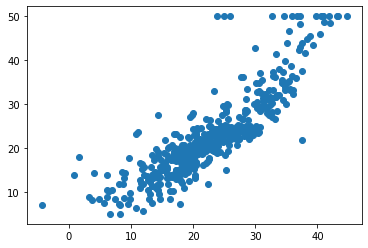

In [10]:
X ,y = load_boston(return_X_y=True)

model = LinearRegression()

model.fit(X,y)

prediction = model.predict(X)

plt.scatter(prediction , y )

##### Transformers

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

df = pd.read_csv("drawndata1.csv")
df.head()

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a
3,262.004361,284.251445,a
4,185.243183,308.187571,a


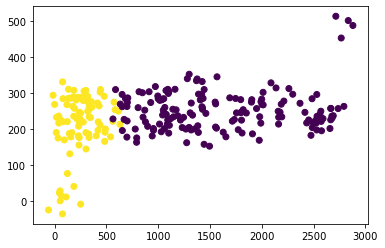

In [12]:
X= df[['x','y']].values
y= df['z'] == 'a'

plt.scatter(X[:,0], X[:,1], c=y);


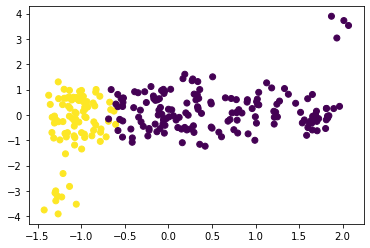

In [13]:
#standardscaler is used to scale the data to have mean 0 and variance 1. It is important to scale the data before training a model, especially for models that are sensitive to the scale of the data, such as KNN, SVM, and neural networks.
from sklearn.preprocessing import StandardScaler

X_new = StandardScaler().fit_transform(X)
plt.scatter(X_new[:,0], X_new[:,1], c=y);



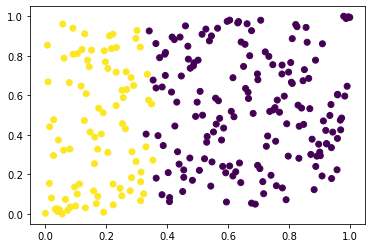

In [14]:
#QuantileTransformer is used to transform the data to follow a uniform or normal distribution. It is useful when the data is not normally distributed and we want to apply algorithms that assume normality, such as linear regression or logistic regression.

from sklearn.preprocessing import QuantileTransformer

X_new = QuantileTransformer(n_quantiles=100).fit_transform(X)
plt.scatter(X_new[:,0], X_new[:,1], c=y);
